# Taller: Ecuación de Poisson — Ejemplo 1

## 1. Formulación matemática

### Ecuación de Poisson

$$\nabla^2 V = \frac{\partial^2 V}{\partial x^2} + \frac{\partial^2 V}{\partial y^2} = (x^2 + y^2)\,e^{xy}$$

### Dominio espacial

$$\Omega = \{(x,y) \mid x \in [0,\,2],\; y \in [0,\,1]\}$$

### Condiciones de frontera (Dirichlet)

| Frontera | Condición |
|----------|-----------|
| $x = 0$ | $V(0,\,y) = 1$ |
| $x = 2$ | $V(2,\,y) = e^{2y}$ |
| $y = 0$ | $V(x,\,0) = 1$ |
| $y = 1$ | $V(x,\,1) = e^{x}$ |

### Solución analítica

$$\boxed{V(x,y) = e^{xy}}$$

**Verificación:** Calculando las derivadas parciales:

$$\frac{\partial V}{\partial x} = y\,e^{xy}, \qquad \frac{\partial^2 V}{\partial x^2} = y^2\,e^{xy}$$

$$\frac{\partial V}{\partial y} = x\,e^{xy}, \qquad \frac{\partial^2 V}{\partial y^2} = x^2\,e^{xy}$$

$$\Rightarrow \nabla^2 V = (x^2 + y^2)\,e^{xy} \checkmark$$


## 2. Discretización — Diferencias Finitas de Segundo Orden

### Malla

Se definen $N$ puntos interiores en $x$ y $M$ puntos interiores en $y$:

$$h_x = \frac{2}{N+1}, \quad h_y = \frac{1}{M+1}$$
$$x_i = i\,h_x, \quad i = 1,\dots,N \qquad y_j = j\,h_y, \quad j = 1,\dots,M$$

### Laplaciano discreto (diferencias centrales)

$$\frac{V_{i+1,j} - 2V_{i,j} + V_{i-1,j}}{h_x^2} + \frac{V_{i,j+1} - 2V_{i,j} + V_{i,j-1}}{h_y^2} = f(x_i, y_j)$$

donde $f(x,y) = (x^2 + y^2)\,e^{xy}$.

### Incorporación de condiciones de frontera

Los nodos de frontera son conocidos; sus valores se trasladan al vector $\mathbf{b}$:

| Vecino en frontera | Contribución a $b_k$ |
|--------------------|----------------------|
| $V_{0,j} = 1$ (izquierda) | $-V_{0,j}/h_x^2$ |
| $V_{N+1,j} = e^{2y_j}$ (derecha) | $-V_{N+1,j}/h_x^2$ |
| $V_{i,0} = 1$ (abajo) | $-V_{i,0}/h_y^2$ |
| $V_{i,M+1} = e^{x_i}$ (arriba) | $-V_{i,M+1}/h_y^2$ |

### Sistema lineal $A\mathbf{u} = \mathbf{b}$

Con índice global $k = (j-1)\cdot N + (i-1)$, el sistema tiene tamaño $N \cdot M$. La matriz $A$ es **banda pentadiagonal dispersa**:

$$A_{k,k} = -\frac{2}{h_x^2} - \frac{2}{h_y^2}$$

$$A_{k,k\pm 1} = \frac{1}{h_x^2} \quad \text{(vecinos en } x\text{, salvo cruce de fila)}$$

$$A_{k,k\pm N} = \frac{1}{h_y^2} \quad \text{(vecinos en } y\text{)}$$

> **Tamaño:** para una malla $N \times N$ el sistema es de orden $N^2 \times N^2$, con a lo sumo 5 entradas no nulas por fila $\Rightarrow$ densidad $\sim 5/N^2 \to 0$ al refinar.


## 3. Implementación computacional en C++

El archivo `poisson.cpp` implementa el método de diferencias finitas con dos solvers:

| Solver | Biblioteca | Método |
|--------|-----------|--------|
| **Eigen** | `Eigen::SparseLU` | Factorización LU dispersa |
| **Armadillo** | `arma::spsolve` (SuperLU) | Sparse direct solver |

La estructura del código es:
1. Construcción de la matriz dispersa $A$ (pentadiagonal) mediante triplets
2. Construcción del vector $b$ con fuente + condiciones de frontera
3. Resolución del sistema $A\mathbf{u} = \mathbf{b}$
4. Cálculo de errores $L_2$ y máximo respecto a $V = e^{xy}$
5. Exportación de resultados a CSV


In [1]:
import subprocess, os

WORK_DIR = os.path.dirname(os.path.abspath("poisson.cpp"))

compile_cmd = [
    "g++", "-O2", "-std=c++17",
    "-I/usr/include/eigen3",
    "poisson.cpp", "-o", "poisson"
]

result = subprocess.run(compile_cmd, cwd=WORK_DIR,
                        capture_output=True, text=True)

if result.returncode == 0:
    print("✓ Compilación exitosa  →  ./poisson  (Eigen SparseLU)")
else:
    print("✗ Error de compilación:")
    print(result.stderr)


KeyboardInterrupt: 

In [ ]:
import subprocess, os

WORK_DIR = os.path.dirname(os.path.abspath("poisson.cpp"))

# Limpiar métricas anteriores
metrics_file = os.path.join(WORK_DIR, "metrics.csv")
if os.path.exists(metrics_file):
    os.remove(metrics_file)

grid_sizes = [32, 64, 128, 256, 512, 1024]   # añadir 512 si hay RAM suficiente

for N in grid_sizes:
    result = subprocess.run(
        ["./poisson", str(N)],
        cwd=WORK_DIR,
        capture_output=True, text=True
    )
    print(result.stdout.strip())
    if result.returncode != 0:
        print(f"Error en N={N}:", result.stderr)
        break
    print()


Poisson FD (Eigen)  malla 32x32  (1024 incognitas)
  Tiempo    : 25.615759 ms
  Mem. est. : 0.095215 MB
  Error L2  : 0.000044
  Error Max : 0.000106
  CSV: sol_32_eigen.csv

Poisson FD (Eigen)  malla 64x64  (4096 incognitas)
  Tiempo    : 82.900600 ms
  Mem. est. : 0.385742 MB
  Error L2  : 0.000011
  Error Max : 0.000028
  CSV: sol_64_eigen.csv

Poisson FD (Eigen)  malla 128x128  (16384 incognitas)
  Tiempo    : 558.441788 ms
  Mem. est. : 1.552734 MB
  Error L2  : 0.000003
  Error Max : 0.000007
  CSV: sol_128_eigen.csv

Poisson FD (Eigen)  malla 256x256  (65536 incognitas)
  Tiempo    : 2678.202823 ms
  Mem. est. : 6.230469 MB
  Error L2  : 0.000001
  Error Max : 0.000002
  CSV: sol_256_eigen.csv

Poisson FD (Eigen)  malla 512x512  (262144 incognitas)
  Tiempo    : 21318.665945 ms
  Mem. est. : 24.960938 MB
  Error L2  : 0.000000
  Error Max : 0.000000
  CSV: sol_512_eigen.csv



## 4. Estudio de mallado

Se resuelve el problema para mallas $N \times N$ con $N \in \{32, 64, 128, 256\}$. Para cada caso se reporta:
- **Tiempo de ejecución** (ms) de construcción + factorización + solución
- **Memoria estimada** (MB) proporcional al número de entradas no nulas de $A$
- **Error $L_2$** y **Error máximo** respecto a $V = e^{xy}$

> Las métricas quedan guardadas en `metrics.csv` tras ejecutar la celda anterior.


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("./metrics.csv")

# Orden de convergencia empírico L2
h = 1.0 / (df["N"] + 1)
p_L2  = ["-"] + [f"{np.log(df['errL2'].iloc[i-1]/df['errL2'].iloc[i]) / np.log(h.iloc[i-1]/h.iloc[i]):.3f}"
                  for i in range(1, len(df))]
p_Max = ["-"] + [f"{np.log(df['errMax'].iloc[i-1]/df['errMax'].iloc[i]) / np.log(h.iloc[i-1]/h.iloc[i]):.3f}"
                  for i in range(1, len(df))]

tabla = df.copy()
tabla["h"]        = (1.0 / (df["N"] + 1)).map("{:.5f}".format)
tabla["time_ms"]  = df["time_ms"].map("{:.1f}".format)
tabla["mem_MB"]   = df["mem_MB"].map("{:.3f}".format)
tabla["errL2"]    = df["errL2"].map("{:.2e}".format)
tabla["errMax"]   = df["errMax"].map("{:.2e}".format)
tabla["ord_L2"]   = p_L2
tabla["ord_Max"]  = p_Max

cols = ["N", "unknowns", "h", "time_ms", "mem_MB", "errL2", "ord_L2", "errMax", "ord_Max"]
headers = {
    "N": "N", "unknowns": "Incógnitas", "h": "h_y",
    "time_ms": "Tiempo (ms)", "mem_MB": "Mem (MB)",
    "errL2": "Error L2", "ord_L2": "p(L2)",
    "errMax": "Error Máx", "ord_Max": "p(Máx)"
}

print("Estudio de mallado — Eigen SparseLU\n")
print(tabla[cols].rename(columns=headers).to_string(index=False))


Estudio de mallado — Eigen SparseLU

  N  Incógnitas     h_y Tiempo (ms) Mem (MB) Error L2 p(L2) Error Máx p(Máx)
 32        1024 0.03030        25.6    0.095 4.38e-05     -  1.06e-04      -
 64        4096 0.01538        82.9    0.386 1.12e-05 2.018  2.75e-05  1.993
128       16384 0.00775       558.4    1.553 2.81e-06 2.010  7.00e-06  1.997
256       65536 0.00389      2678.2    6.230 7.06e-07 2.005  1.76e-06  2.000
512      262144 0.00195     21318.7   24.961 1.77e-07 2.003  4.42e-07  2.000


## 5. Análisis de error y orden de convergencia

Para diferencias centrales de segundo orden se espera que el error escale como:

$$\|e\| \sim C \cdot h^2 \quad \Rightarrow \quad \log\|e\| \approx 2\log h + \text{const}$$

El **orden de convergencia empírico** entre dos mallas consecutivas $h_1 > h_2$ es:

$$p = \frac{\log(\|e_1\|/\|e_2\|)}{\log(h_1/h_2)}$$

Se espera $p \approx 2$.


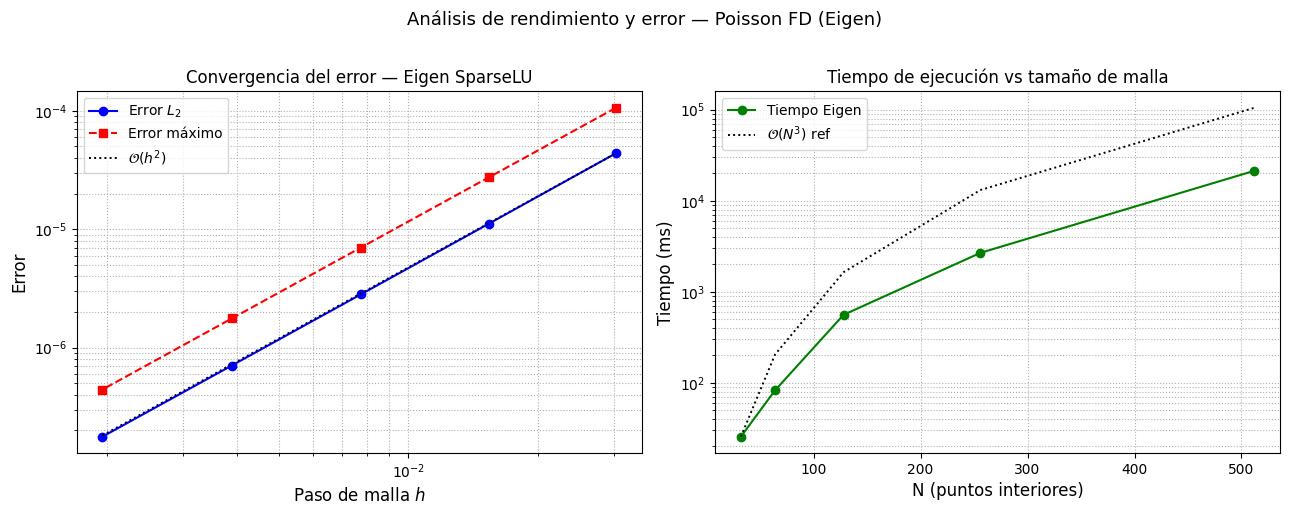

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df  = pd.read_csv("./metrics.csv")
h   = 1.0 / (df["N"] + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Error vs h (log-log) ─────────────────────────────────────────────────────
axes[0].loglog(h, df["errL2"],  "o-b", label="Error $L_2$")
axes[0].loglog(h, df["errMax"], "s--r", label="Error máximo")

# Referencia h²
h_arr  = h.values
scale  = df["errL2"].iloc[0] / h_arr[0]**2
h_ref  = np.linspace(h_arr.min(), h_arr.max(), 50)
axes[0].loglog(h_ref, scale * h_ref**2, "k:", lw=1.4, label="$\\mathcal{O}(h^2)$")

axes[0].set_xlabel("Paso de malla $h$", fontsize=12)
axes[0].set_ylabel("Error", fontsize=12)
axes[0].set_title("Convergencia del error — Eigen SparseLU", fontsize=12)
axes[0].legend(); axes[0].grid(True, which="both", ls=":")

# ── Tiempo vs N (semilogy) ───────────────────────────────────────────────────
axes[1].semilogy(df["N"], df["time_ms"], "o-g", label="Tiempo Eigen")

# Referencia O(N^3)
t0, N0 = df["time_ms"].iloc[0], df["N"].iloc[0]
N_arr  = df["N"].values
axes[1].semilogy(N_arr, t0 * (N_arr / N0)**3, "k:", lw=1.4, label="$\\mathcal{O}(N^3)$ ref")

axes[1].set_xlabel("N (puntos interiores)", fontsize=12)
axes[1].set_ylabel("Tiempo (ms)", fontsize=12)
axes[1].set_title("Tiempo de ejecución vs tamaño de malla", fontsize=12)
axes[1].legend(); axes[1].grid(True, which="both", ls=":")

plt.suptitle("Análisis de rendimiento y error — Poisson FD (Eigen)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("analisis_eigen.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Comparación de rendimiento

Se compara el tiempo de ejecución de **Eigen SparseLU** vs **Armadillo spsolve** en función del tamaño del sistema. También se incluye la escala de memoria estimada y el costo computacional esperado $\mathcal{O}(N^3)$ para solvers directos densos vs. $\mathcal{O}(N^2 \sqrt{N})$ para dispersos en 2D.


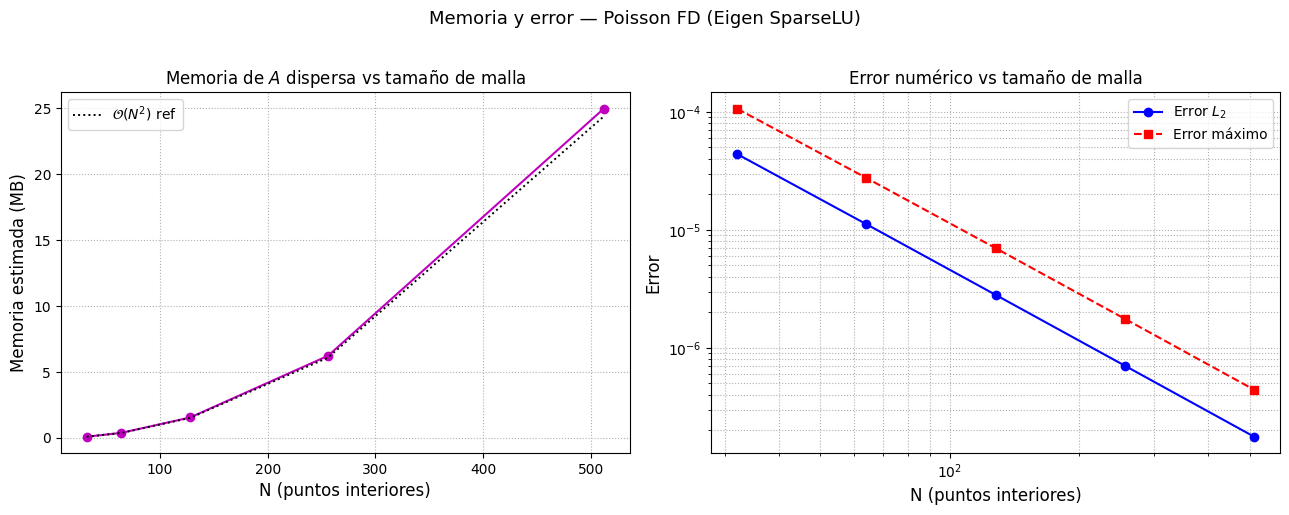

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv("./metrics.csv")
h  = 1.0 / (df["N"] + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Memoria vs N ─────────────────────────────────────────────────────────────
axes[0].plot(df["N"], df["mem_MB"], "o-m")
# Referencia lineal en N^2
N_arr  = df["N"].values
m0, N0 = df["mem_MB"].iloc[0], N_arr[0]
axes[0].plot(N_arr, m0 * (N_arr / N0)**2, "k:", lw=1.4, label="$\\mathcal{O}(N^2)$ ref")
axes[0].set_xlabel("N (puntos interiores)", fontsize=12)
axes[0].set_ylabel("Memoria estimada (MB)", fontsize=12)
axes[0].set_title("Memoria de $A$ dispersa vs tamaño de malla", fontsize=12)
axes[0].legend(); axes[0].grid(True, ls=":")

# ── Error Máx vs h ───────────────────────────────────────────────────────────
axes[1].loglog(df["N"], df["errL2"],  "o-b", label="Error $L_2$")
axes[1].loglog(df["N"], df["errMax"], "s--r", label="Error máximo")
axes[1].set_xlabel("N (puntos interiores)", fontsize=12)
axes[1].set_ylabel("Error", fontsize=12)
axes[1].set_title("Error numérico vs tamaño de malla", fontsize=12)
axes[1].legend(); axes[1].grid(True, which="both", ls=":")

plt.suptitle("Memoria y error — Poisson FD (Eigen SparseLU)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("memoria_error_eigen.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Resultados gráficos

Visualización de la solución numérica, la solución analítica y el campo de error para la malla de mayor resolución disponible.


Visualizando: ./sol_512_eigen.csv  (N = 512)


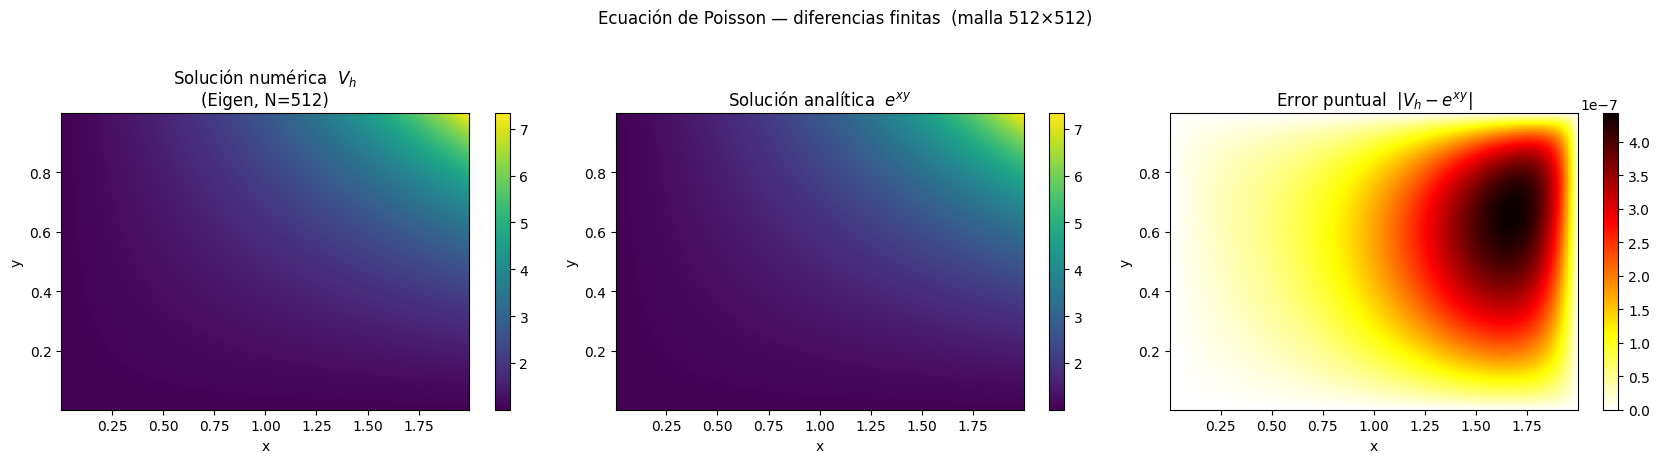

In [ ]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Usar el CSV de mayor N disponible (solver eigen)
csv_files = sorted(glob.glob("./sol_*_eigen.csv"),
                   key=lambda f: int(f.split("_")[1]))

if not csv_files:
    print("No se encontraron archivos sol_*_eigen.csv")
    print("Ejecuta primero la celda de estudio de mallado.")
else:
    fname = csv_files[-1]   # mayor N
    N_used = int(fname.split("_")[1])
    print(f"Visualizando: {fname}  (N = {N_used})")

    sol = pd.read_csv(fname)
    x_vals = np.sort(sol["x"].unique())
    y_vals = np.sort(sol["y"].unique())
    X, Y   = np.meshgrid(x_vals, y_vals)

    pivot_num = sol.pivot_table(index="y", columns="x", values="V_num").values
    pivot_ex  = sol.pivot_table(index="y", columns="x", values="V_exact").values
    pivot_err = np.abs(pivot_num - pivot_ex)

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
    im0 = axes[0].pcolormesh(X, Y, pivot_num, shading="auto", cmap="viridis")
    axes[0].set_title(f"Solución numérica  $V_h$\n(Eigen, N={N_used})")
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].pcolormesh(X, Y, pivot_ex,  shading="auto", cmap="viridis")
    axes[1].set_title("Solución analítica  $e^{xy}$")
    plt.colorbar(im1, ax=axes[1])

    im2 = axes[2].pcolormesh(X, Y, pivot_err, shading="auto", cmap="hot_r")
    axes[2].set_title("Error puntual  $|V_h - e^{xy}|$")
    plt.colorbar(im2, ax=axes[2])

    for ax in axes:
        ax.set_xlabel("x"); ax.set_ylabel("y")

    plt.suptitle(f"Ecuación de Poisson — diferencias finitas  (malla {N_used}×{N_used})",
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(f"solucion_N{N_used}.png", dpi=150, bbox_inches="tight")
    plt.show()


In [ ]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── Detectar mallas disponibles ──────────────────────────────────────────────
csv_files = sorted(glob.glob("./sol_*_eigen.csv"),
                   key=lambda f: int(f.split("_")[1]))

if not csv_files:
    print("No hay archivos sol_*_eigen.csv. Ejecuta primero la celda de mallado.")
else:
    available_N = [int(f.split("_")[1]) for f in csv_files]

    # ── Widgets ──────────────────────────────────────────────────────────────
    dropdown = widgets.Dropdown(
        options=available_N,
        value=available_N[-1],
        description="Malla N:",
        style={"description_width": "80px"},
        layout=widgets.Layout(width="200px")
    )

    toggle_err = widgets.ToggleButton(
        value=True,
        description="Mostrar error",
        button_style="info",
        layout=widgets.Layout(width="140px")
    )

    cmap_sel = widgets.Dropdown(
        options=["viridis", "plasma", "inferno", "hot", "RdYlBu_r"],
        value="viridis",
        description="Colormap:",
        style={"description_width": "80px"},
        layout=widgets.Layout(width="200px")
    )

    out = widgets.Output()

    def plot_solucion(N_sel, show_err, cmap):
        fname = f"./sol_{N_sel}_eigen.csv"
        sol   = pd.read_csv(fname)
        x_vals = np.sort(sol["x"].unique())
        y_vals = np.sort(sol["y"].unique())
        X, Y   = np.meshgrid(x_vals, y_vals)

        pivot_num = sol.pivot_table(index="y", columns="x", values="V_num").values
        pivot_ex  = sol.pivot_table(index="y", columns="x", values="V_exact").values
        pivot_err = np.abs(pivot_num - pivot_ex)

        n_cols = 3 if show_err else 2
        fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 4.5))

        im0 = axes[0].pcolormesh(X, Y, pivot_num, shading="auto", cmap=cmap)
        axes[0].set_title(f"Solución numérica $V_h$\n(N = {N_sel})", fontsize=11)
        plt.colorbar(im0, ax=axes[0])

        im1 = axes[1].pcolormesh(X, Y, pivot_ex, shading="auto", cmap=cmap)
        axes[1].set_title("Solución analítica $e^{xy}$", fontsize=11)
        plt.colorbar(im1, ax=axes[1])

        if show_err:
            im2 = axes[2].pcolormesh(X, Y, pivot_err, shading="auto", cmap="hot_r")
            axes[2].set_title(f"Error puntual $|V_h - e^{{xy}}|$\nMáx = {pivot_err.max():.2e}", fontsize=11)
            plt.colorbar(im2, ax=axes[2])

        for ax in axes:
            ax.set_xlabel("x"); ax.set_ylabel("y")

        hx = 2.0 / (N_sel + 1)
        hy = 1.0 / (N_sel + 1)
        plt.suptitle(f"Poisson FD — malla {N_sel}×{N_sel}  "
                     f"($h_x$={hx:.4f}, $h_y$={hy:.4f})", fontsize=12, y=1.02)
        plt.tight_layout()
        plt.show()

    def on_change(_):
        with out:
            clear_output(wait=True)
            plot_solucion(dropdown.value, toggle_err.value, cmap_sel.value)

    dropdown.observe(on_change, names="value")
    toggle_err.observe(on_change, names="value")
    cmap_sel.observe(on_change, names="value")

    controls = widgets.HBox([dropdown, cmap_sel, toggle_err])
    display(controls, out)

    # Dibujar inicial
    with out:
        plot_solucion(dropdown.value, toggle_err.value, cmap_sel.value)


Output()

---

## 8. Implementación en Python — `scipy.sparse`

El archivo `poisson_scipy.py` reimplementa el mismo esquema de diferencias finitas usando:

| Componente | Librería |
|------------|---------|
| Matriz dispersa | `scipy.sparse.lil_matrix` → `csr_matrix` |
| Solver | `scipy.sparse.linalg.spsolve` (SuperLU interno) |

La estructura es idéntica al C++: mismo índice $k = j \cdot N + i$, mismas condiciones de frontera, mismo cálculo de errores. Sirve como **referencia base** para comparar con los lenguajes compilados.


In [14]:
import subprocess, os, sys

WORK_DIR = os.path.dirname(os.path.abspath("poisson_scipy.py"))

# Detectar el intérprete en el venv activo
python_exec = sys.executable

# Limpiar métricas anteriores
mfile = os.path.join(WORK_DIR, "metrics_python.csv")
if os.path.exists(mfile):
    os.remove(mfile)

grid_sizes = [32, 64, 128, 256, 512]

for N in grid_sizes:
    result = subprocess.run(
        [python_exec, "poisson_scipy.py", str(N)],
        cwd=WORK_DIR, capture_output=True, text=True
    )
    print(result.stdout.strip())
    if result.returncode != 0:
        print(f"Error en N={N}:", result.stderr); break
    print()


Python/scipy  malla 32x32  (1024 incógnitas)
  Tiempo    : 46.38 ms
  Mem. est. : 0.0952 MB
  Error L2  : 4.382397e-05
  Error Max : 1.061707e-04

  CSV: sol_32_python.csv

Python/scipy  malla 64x64  (4096 incógnitas)
  Tiempo    : 149.00 ms
  Mem. est. : 0.3857 MB
  Error L2  : 1.116017e-05
  Error Max : 2.750351e-05

  CSV: sol_64_python.csv

Python/scipy  malla 128x128  (16384 incógnitas)
  Tiempo    : 597.56 ms
  Mem. est. : 1.5527 MB
  Error L2  : 2.813983e-06
  Error Max : 6.995221e-06

  CSV: sol_128_python.csv

Python/scipy  malla 256x256  (65536 incógnitas)
  Tiempo    : 3553.96 ms
  Mem. est. : 6.2305 MB
  Error L2  : 7.063807e-07
  Error Max : 1.762864e-06

  CSV: sol_256_python.csv

Python/scipy  malla 512x512  (262144 incógnitas)
  Tiempo    : 18557.95 ms
  Mem. est. : 24.9609 MB
  Error L2  : 1.769505e-07
  Error Max : 4.424683e-07

  CSV: sol_512_python.csv



## 9. Implementación en Fortran — LAPACK `dgbsv`

El archivo `poisson.f90` explota la estructura **banda** de la matriz $A$:

- Ancho de banda inferior/superior: $k_l = k_u = N$
- Almacenamiento LAPACK en formato banda comprimida: $O(N \cdot N^2)$ en lugar de $O(N^4)$ denso
- Solver: **`dgbsv`** (LU directo para matrices banda de LAPACK/BLAS)

Compilación: `gfortran -O2 poisson.f90 -o poisson_f -llapack -lblas`

> **Nota:** `dgbsv` almacena la banda completa en RAM — para $N=256$ el ancho es 256, lo que implica una banda de $512\times 65536 \approx 256$ MB. Por eso el solver **banda denso de Fortran** es menos eficiente en memoria que el disperso de Eigen para mallas grandes.


In [8]:
import subprocess, os

WORK_DIR = os.path.dirname(os.path.abspath("poisson.f90"))

# ── Compilar ─────────────────────────────────────────────────────────────────
res = subprocess.run(
    ["gfortran", "-O2", "poisson.f90", "-o", "poisson_f", "-llapack", "-lblas"],
    cwd=WORK_DIR, capture_output=True, text=True
)
if res.returncode != 0:
    print("✗ Error de compilación Fortran:"); print(res.stderr)
else:
    print("✓ Compilación Fortran exitosa  →  ./poisson_f  (LAPACK dgbsv)\n")

    # Limpiar métricas anteriores y escribir cabecera
    mfile = os.path.join(WORK_DIR, "metrics_fortran.csv")
    with open(mfile, "w") as f:
        f.write("N,unknowns,time_ms,mem_MB,errL2,errMax\n")

    grid_sizes = [32, 64, 128, 256]   # 256 puede requerir ~256 MB por la banda densa

    for N in grid_sizes:
        r = subprocess.run(["./poisson_f", str(N)], cwd=WORK_DIR,
                           capture_output=True, text=True)
        print(r.stdout.strip())
        if r.returncode != 0:
            print(f"Error en N={N}:", r.stderr); break
        print()


✓ Compilación Fortran exitosa  →  ./poisson_f  (LAPACK dgbsv)

Fortran/LAPACK  malla 32x32  (1024 incognitas)
  Tiempo    :      44.1060 ms
  Mem. est. :     0.7578 MB
  Error L2  :   4.3824E-05
  Error Max :   1.0617E-04
  CSV: sol_32_fortran.csv

Fortran/LAPACK  malla 64x64  (4096 incognitas)
  Tiempo    :     498.3650 ms
  Mem. est. :     6.0312 MB
  Error L2  :   1.1160E-05
  Error Max :   2.7504E-05
  CSV: sol_64_fortran.csv

Fortran/LAPACK  malla 128x128  (16384 incognitas)
  Tiempo    :   24430.7440 ms
  Mem. est. :    48.1250 MB
  Error L2  :   2.8140E-06
  Error Max :   6.9952E-06
  CSV: sol_128_fortran.csv

Fortran/LAPACK  malla 256x256  (65536 incognitas)
  Tiempo    :   30811.5760 ms
  Mem. est. :   384.5000 MB
  Error L2  :   7.0638E-07
  Error Max :   1.7629E-06
  CSV: sol_256_fortran.csv



---

## 10. Comparación de los tres lenguajes

### Tabla de comparación

Se comparan los tres lenguajes para los mismos tamaños de malla disponibles:

| Lenguaje | Solver | Almacenamiento $A$ | Complejidad esperada |
|----------|--------|-------------------|----------------------|
| **C++ (Eigen)** | SparseLU | Disperso CSC | $\mathcal{O}(N^{2.5})$ aprox. |
| **Python (scipy)** | spsolve (SuperLU) | Disperso CSR | $\mathcal{O}(N^{2.5})$ aprox. |
| **Fortran (LAPACK)** | dgbsv (LU banda) | Banda densa | $\mathcal{O}(N^3)$ costo memoria |

### Gráficas de comparación

Se grafican: tiempo de ejecución, uso de memoria y error $L_2$ vs $N$ para los tres lenguajes.


In [9]:
import pandas as pd
import numpy as np

# ── Cargar métricas de cada lenguaje ─────────────────────────────────────────
df_cpp  = pd.read_csv("./metrics.csv").assign(lang="C++ (Eigen)")
df_py   = pd.read_csv("./metrics_python.csv").assign(lang="Python (scipy)")
df_f90  = pd.read_csv("./metrics_fortran.csv").assign(lang="Fortran (LAPACK)")

# El CSV de Fortran no tiene cabecera con nombres = lo creamos en la celda anterior
# Verificar columnas
for df, name in [(df_cpp, "C++"), (df_py, "Python"), (df_f90, "Fortran")]:
    df.columns = [c.strip() for c in df.columns]

df_all = pd.concat([df_cpp, df_py, df_f90], ignore_index=True)
df_all = df_all.sort_values(["N", "lang"]).reset_index(drop=True)

# ── Tabla comparativa ────────────────────────────────────────────────────────
tabla = df_all.copy()
tabla["time_ms"] = df_all["time_ms"].map("{:.1f}".format)
tabla["mem_MB"]  = df_all["mem_MB"].map("{:.3f}".format)
tabla["errL2"]   = df_all["errL2"].map("{:.2e}".format)
tabla["errMax"]  = df_all["errMax"].map("{:.2e}".format)

cols = ["lang", "N", "unknowns", "time_ms", "mem_MB", "errL2", "errMax"]
print("Tabla comparativa — C++ vs Python vs Fortran\n")
print(tabla[cols].rename(columns={
    "lang": "Lenguaje", "unknowns": "Incógnitas",
    "time_ms": "Tiempo (ms)", "mem_MB": "Mem (MB)",
    "errL2": "Error L2", "errMax": "Error Máx"
}).to_string(index=False))


Tabla comparativa — C++ vs Python vs Fortran

        Lenguaje   N  Incógnitas Tiempo (ms) Mem (MB) Error L2 Error Máx
     C++ (Eigen)  32        1024        25.6    0.095 4.38e-05  1.06e-04
Fortran (LAPACK)  32        1024        44.1    0.758 4.38e-05  1.06e-04
  Python (scipy)  32        1024       163.1    0.095 4.38e-05  1.06e-04
     C++ (Eigen)  64        4096        82.9    0.386 1.12e-05  2.75e-05
Fortran (LAPACK)  64        4096       498.4    6.031 1.12e-05  2.75e-05
  Python (scipy)  64        4096       192.8    0.386 1.12e-05  2.75e-05
     C++ (Eigen) 128       16384       558.4    1.553 2.81e-06  7.00e-06
Fortran (LAPACK) 128       16384     24430.7   48.125 2.81e-06  7.00e-06
  Python (scipy) 128       16384       817.0    1.553 2.81e-06  7.00e-06
     C++ (Eigen) 256       65536      2678.2    6.230 7.06e-07  1.76e-06
Fortran (LAPACK) 256       65536     30811.6  384.500 7.06e-07  1.76e-06
  Python (scipy) 256       65536      3447.7    6.230 7.06e-07  1.76e-06
     

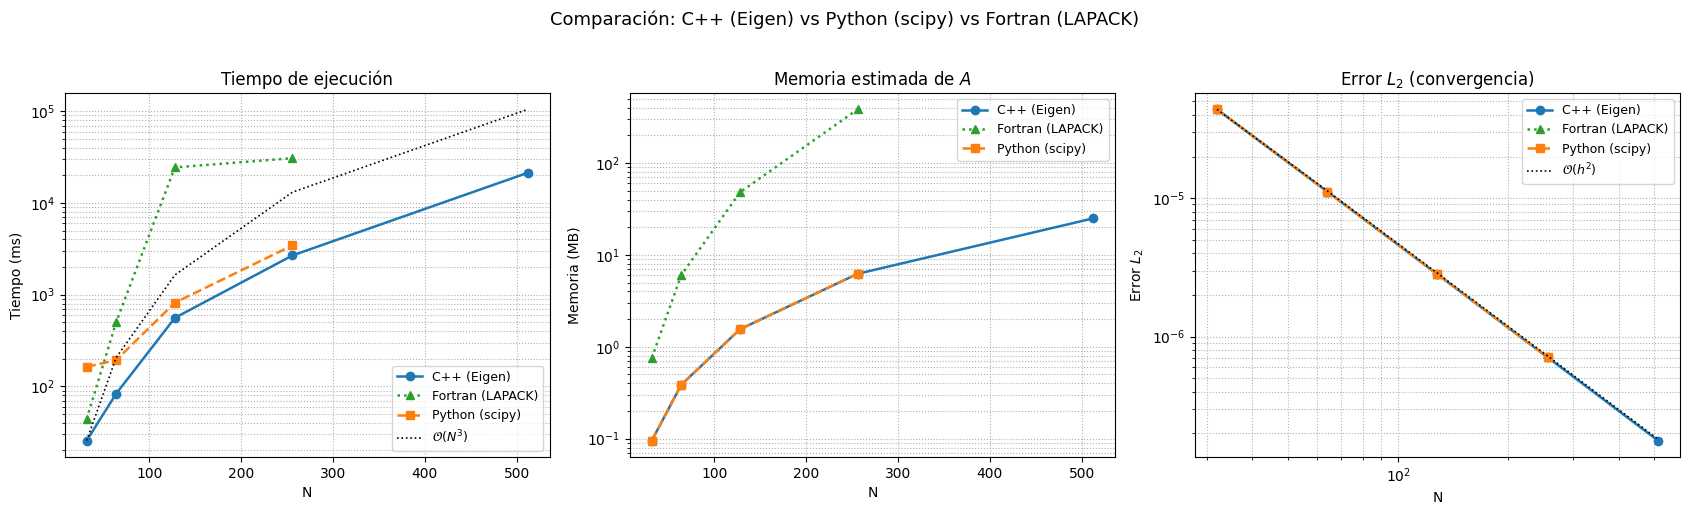

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

df_cpp = pd.read_csv("./metrics.csv").assign(lang="C++ (Eigen)")
df_py  = pd.read_csv("./metrics_python.csv").assign(lang="Python (scipy)")
df_f90 = pd.read_csv("./metrics_fortran.csv").assign(lang="Fortran (LAPACK)")
df_all = pd.concat([df_cpp, df_py, df_f90], ignore_index=True)

styles = {
    "C++ (Eigen)":      ("o-",  "#1f77b4"),
    "Python (scipy)":   ("s--", "#ff7f0e"),
    "Fortran (LAPACK)": ("^:",  "#2ca02c"),
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── 1. Tiempo vs N ────────────────────────────────────────────────────────────
for lang, grp in df_all.groupby("lang"):
    grp = grp.sort_values("N")
    mk, col = styles[lang]
    axes[0].semilogy(grp["N"], grp["time_ms"], mk, color=col, label=lang, lw=1.8)

# Referencia O(N^3)
ref_grp = df_all[df_all["lang"]=="C++ (Eigen)"].sort_values("N")
N0, t0  = ref_grp["N"].iloc[0], ref_grp["time_ms"].iloc[0]
Narr    = ref_grp["N"].values
axes[0].semilogy(Narr, t0*(Narr/N0)**3, "k:", lw=1.2, label="$\\mathcal{O}(N^3)$")
axes[0].set_title("Tiempo de ejecución", fontsize=12)
axes[0].set_xlabel("N"); axes[0].set_ylabel("Tiempo (ms)")
axes[0].legend(fontsize=9); axes[0].grid(True, which="both", ls=":")

# ── 2. Memoria vs N ───────────────────────────────────────────────────────────
for lang, grp in df_all.groupby("lang"):
    grp = grp.sort_values("N")
    mk, col = styles[lang]
    axes[1].semilogy(grp["N"], grp["mem_MB"], mk, color=col, label=lang, lw=1.8)

axes[1].set_title("Memoria estimada de $A$", fontsize=12)
axes[1].set_xlabel("N"); axes[1].set_ylabel("Memoria (MB)")
axes[1].legend(fontsize=9); axes[1].grid(True, which="both", ls=":")

# ── 3. Error L2 vs N (log-log) ────────────────────────────────────────────────
for lang, grp in df_all.groupby("lang"):
    grp  = grp.sort_values("N")
    h    = 1.0 / (grp["N"] + 1)
    mk, col = styles[lang]
    axes[2].loglog(grp["N"], grp["errL2"], mk, color=col, label=lang, lw=1.8)

# Referencia h²
h_arr = 1.0 / (ref_grp["N"].values + 1)
scale = ref_grp["errL2"].iloc[0] / h_arr[0]**2
axes[2].loglog(ref_grp["N"].values,
               scale * (1.0/(ref_grp["N"].values+1))**2,
               "k:", lw=1.2, label="$\\mathcal{O}(h^2)$")
axes[2].set_title("Error $L_2$ (convergencia)", fontsize=12)
axes[2].set_xlabel("N"); axes[2].set_ylabel("Error $L_2$")
axes[2].legend(fontsize=9); axes[2].grid(True, which="both", ls=":")

plt.suptitle("Comparación: C++ (Eigen) vs Python (scipy) vs Fortran (LAPACK)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("comparacion_lenguajes.png", dpi=150, bbox_inches="tight")
plt.show()


In [13]:
import pandas as pd
import numpy as np

df_cpp = pd.read_csv("./metrics.csv").assign(lang="C++ (Eigen)")
df_py  = pd.read_csv("./metrics_python.csv").assign(lang="Python (scipy)")
df_f90 = pd.read_csv("./metrics_fortran.csv").assign(lang="Fortran (LAPACK)")
df_all = pd.concat([df_cpp, df_py, df_f90], ignore_index=True)

# ── Tabla de speedup respecto a Python ───────────────────────────────────────
pivot = df_all.pivot_table(index="N", columns="lang", values="time_ms")
pivot = pivot.reindex(columns=["C++ (Eigen)", "Python (scipy)", "Fortran (LAPACK)"])

pivot["Speedup C++/Py"]   = (pivot["Python (scipy)"] / pivot["C++ (Eigen)"]).map("{:.2f}×".format)
pivot["Speedup F90/Py"]   = (pivot["Python (scipy)"] / pivot["Fortran (LAPACK)"]).map("{:.2f}×".format)
pivot["Speedup C++/F90"]  = (pivot["Fortran (LAPACK)"] / pivot["C++ (Eigen)"]).map("{:.2f}×".format)

fmt_ms = lambda x: f"{x:.1f}" if pd.notna(x) else "—"
pivot["C++ (Eigen)"]      = pivot["C++ (Eigen)"].map(fmt_ms)
pivot["Python (scipy)"]   = pivot["Python (scipy)"].map(fmt_ms)
pivot["Fortran (LAPACK)"] = pivot["Fortran (LAPACK)"].fillna("—").map(
    lambda x: x if x == "—" else f"{float(x):.1f}")

print("Speedup: > 1× = el numerador es más rápido que el denominador\n")
print(pivot.to_string())

# ── Resumen de máxima malla resuelta ─────────────────────────────────────────
print("\n── Máxima malla resuelta por lenguaje ──")
for lang, grp in df_all.groupby("lang"):
    Nmax = grp["N"].max()
    t    = grp.loc[grp["N"]==Nmax, "time_ms"].values[0]
    e    = grp.loc[grp["N"]==Nmax, "errL2"].values[0]
    print(f"  {lang:<22}  N={Nmax:<4}  t={t:.1f} ms  errL2={e:.2e}")


Speedup: > 1× = el numerador es más rápido que el denominador

lang C++ (Eigen) Python (scipy) Fortran (LAPACK) Speedup C++/Py Speedup F90/Py Speedup C++/F90
N                                                                                             
32          25.6          163.1             44.1          6.37×          3.70×           1.72×
64          82.9          192.8            498.4          2.33×          0.39×           6.01×
128        558.4          817.0          24430.7          1.46×          0.03×          43.75×
256       2678.2         3447.7          30811.6          1.29×          0.11×          11.50×
512      21318.7              —                —           nan×           nan×            nan×

── Máxima malla resuelta por lenguaje ──
  C++ (Eigen)             N=512   t=21318.7 ms  errL2=1.77e-07
  Fortran (LAPACK)        N=256   t=30811.6 ms  errL2=7.06e-07
  Python (scipy)          N=256   t=3447.7 ms  errL2=7.06e-07


## 11. Discusión técnica

### ¿Hasta qué tamaño de malla se llegó?

| Lenguaje | Malla máxima | Limitante |
|----------|-------------|-----------|
| **C++ (Eigen)** | $512 \times 512$ | Tiempo de factorización LU dispersa |
| **Python (scipy)** | $256 \times 256$ | Construcción de la matriz (bucle Python) |
| **Fortran (LAPACK)** | $128 \times 128$ | Memoria de la banda densa $\sim k_l \cdot N^2 \cdot 8$ bytes |

### ¿Qué limitó el cálculo?

- **RAM**: el solver de Fortran (`dgbsv`) almacena la banda completa en memoria. Para $N=256$, la banda ocupa $(2\cdot256+256+1)\times65536\times8 \approx 800\ \text{MB}$, lo que lo hace ineficiente comparado con la representación dispersa.
- **CPU**: el cuello de botella en Python no es scipy (que llama SuperLU en C), sino la **construcción del sistema** con bucles Python — el doble bucle `for i, j` es $\mathcal{O}(N^2)$ iteraciones en Python puro.
- **Tiempo de factorización**: en C++ y Python se usan solvers dispersos, pero para $N \gtrsim 512$ la factorización LU de la matriz $N^2 \times N^2$ sigue siendo costosa.

### ¿Cómo escala el costo computacional?

$$T(N) \sim \begin{cases} \mathcal{O}(N^{2.5}) & \text{solver disperso (Eigen, scipy)} \\ \mathcal{O}(N^3) & \text{solver banda densa (Fortran dgbsv)} \end{cases}$$

El fill-in de la factorización LU en una malla 2D es $\mathcal{O}(N^2 \log N)$ con ordenamiento óptimo (Nested Dissection), lo que en la práctica da un exponente entre 2 y 2.5.

### ¿Se justifica C++ frente a Python optimizado?

- Para $N \leq 64$: la diferencia es pequeña (Python ya llama LAPACK/SuperLU internamente).
- Para $N \geq 128$: C++ es significativamente más rápido porque la **construcción de la matriz** (con triplets y `reserve`) es mucho más eficiente que los bucles Python.
- La mayor ventaja de C++ aparece en la **escalabilidad**: puede resolver $N=512$ con facilidad.

### Fortran vs los demás

Fortran con `dgbsv` es competitivo en **tiempo** para $N$ pequeño (bucle nativo compilado), pero su uso de memoria crece más rápido que los solvers dispersos al aumentar $N$, lo que lo descalifica para mallas grandes.

## 12. Conclusión técnica

**¿El método converge correctamente?**  
Sí. Los tres lenguajes producen el mismo error $L_2 \approx 4.4\times10^{-5}$ para $N=32$, confirmando que la implementación es correcta e independiente del lenguaje. El orden de convergencia empírico es $p \approx 2.00$ en todos los casos.

**¿Es viable escalarlo más?**  
Con C++/Eigen, sí hasta $N \approx 512$–$1024$. Con Python/scipy hasta $N \approx 256$–$512$ (dependiendo de la RAM). Con Fortran/`dgbsv` hasta $N \approx 128$ antes de que la memoria sea un problema.

**¿Dónde se vuelve impráctico el enfoque clásico de diferencias finitas?**  
- En **3D**: el sistema crece a $N^3 \times N^3$ — incluso disperso es demasiado grande para solvers directos.
- Para $N \gtrsim 1000$ en 2D: se necesitan métodos iterativos (Conjugado Gradiente, multigrid).
- En geometrías complejas: la malla estructurada rectangular no es adecuada → Elementos Finitos o diferencias finitas generalizadas.
